In [1]:
from utils import read_gbq
import matplotlib.pyplot as plt
from tableone import TableOne
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import os
from utils import read_gbq, rename_cols #,compute_effect_per_unit
import matplotlib.pyplot as plt
from tableone import TableOne
from collections import Counter
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import os
from tqdm import tqdm
from utils import treatment_effect
from scipy.stats import norm, zscore

warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv('df_official_april10.csv')

In [3]:
WINDOW_SIZE=12
OFFSET=6

In [4]:
PROCEDURES=Path("./procedures")
# PROJECT_ID=os.getenv('PROJECTID')
PROJECT_ID="physio-414520"

In [5]:
import google.auth

creds, project = google.auth.default()

print("Project:", project)
print("Service account:", getattr(creds, "service_account_email", None))
print("Quota project:", getattr(creds, "quota_project_id", None))

Project: physio-414520
Service account: None
Quota project: physio-414520


In [6]:
# # Transfusiuon Data
transfusion_df=read_gbq(PROCEDURES / "transfusion.sql",project_id=PROJECT_ID)
transfusion_df=transfusion_df.sort_values(by=['patientunitstayid','offset'])
transfusion_df.offset=transfusion_df.offset/60

# HGB Data
hgb_df=read_gbq(PROCEDURES / "hgb.sql",project_id=PROJECT_ID)
hgb_df=hgb_df.sort_values(by=['patientunitstayid','offset'])
hgb_df.offset=hgb_df.offset/60
     
# Apache Data        
apache_df=read_gbq(PROCEDURES / "apache.sql",project_id=PROJECT_ID)        
apache_df=apache_df.sort_values(by=['patientunitstayid'])        
        
# Fluids Data        
fluids_df=read_gbq(PROCEDURES / "fluid_balance.sql",project_id=PROJECT_ID)        
fluids_df=fluids_df.sort_values(by=['patientunitstayid','transfusion_offset'])        
fluids_df.transfusion_offset=fluids_df.transfusion_offset/60        
        
# Demographic data         
demographics_df=read_gbq(PROCEDURES / "demographics.sql",project_id=PROJECT_ID)        
        
# GI Bleeder        
gb_df=read_gbq(PROCEDURES / "gb.sql",project_id=PROJECT_ID)        
gb_df['gi_bleeder']=True        
        
# Length of stay        
lengthStay_df = (read_gbq(PROCEDURES / "lengthStay.sql", project_id=PROJECT_ID)
                 .sort_values(by=['patientunitstayid']))
time_columns = ['ICU_Stay', 'Time_prior_ICU', 'hospitalDischargeOffset']        
lengthStay_df[time_columns] = lengthStay_df[time_columns] / 60
lengthStay_df['Total_time'] = lengthStay_df['hospitalDischargeOffset'] - lengthStay_df['Time_prior_ICU']        
        
# # Vitals        
vitals = (read_gbq(PROCEDURES / "vitals.sql", project_id=PROJECT_ID)        
                 .sort_values(by=['patientunitstayid']))        
vitals.intakeoutputoffset=vitals.intakeoutputoffset/60        

Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|


In [7]:
import utils

demographics_df["hematologic_type"] = demographics_df["admit_diagnosis"].apply(
    lambda x: utils.find_condition_type(x, category="hematologic")
)

demographics_df["kidney_type"] = demographics_df["admit_diagnosis"].apply(
    lambda x: utils.find_condition_type(x, category="kidney")
)

from utils import classify_condition_category

demographics_df["condition_category"] = demographics_df["admit_diagnosis"].apply(classify_condition_category)


In [8]:
# Giovanni : utils.treatment_effect computes the average (or any function you want) HGB in window size before transfusion (treatment) as baseline_hgb(g/dl)
# and after transfusion intitiation + a OFFSET for estimating the post treatment effect

data=[]
for ix,group in tqdm(transfusion_df.groupby('patientunitstayid')):
    data.append(treatment_effect(
        group,
        hgb_df[hgb_df.patientunitstayid.isin(group.patientunitstayid)],
        WINDOW_SIZE,
        OFFSET,
        'mean')
        )

def merge_info(original, to_merge, merge_by):
    filter_merge =  to_merge[to_merge[merge_by].isin(original[merge_by].unique())]
    merged = pd.merge(original, filter_merge, how='left')
    return merged

100%|██████████| 19694/19694 [04:56<00:00, 66.49it/s] 


In [9]:
df=pd.concat(data).groupby('patientunitstayid').first().reset_index() # for now we only keep the first transfusion


df=df.merge(demographics_df,on='patientunitstayid',validate='1:1')
# df.age=df.age.replace('> 89',91).astype(float)
df.age=df.age.replace('> 89', 91)
df.age=pd.to_numeric(df.age, errors='coerce')

print(df['patientunitstayid'].nunique())

df=df[df['age'] >= 18]
print('Age', df['patientunitstayid'].nunique())

# 20 patients lower than 18

df=df[~df['patientunitstayid'].isin(gb_df['patientunitstayid'].unique())]
print('GI',df['patientunitstayid'].nunique())
# GI bleeders: 469
# Also removed GI bleeders in demographics query

post=df[df['post_treatment'].isna()]
df=df[df['post_treatment'].notna()]
print('post', df['patientunitstayid'].nunique())


base=df[df['baseline'].isna()]
df=df[df['baseline'].notna()]
print('baseline', df['patientunitstayid'].nunique())

15289
Age 15269
GI 15158
post 12255
baseline 10578


In [10]:
def compute_unit(row):
    if pd.isna(row['treatment_value']):
        return np.nan
    if row['treatment_effect'] == 0:
        return 0.0
    return row['treatment_value'] / 330.0
    
df['units'] = df.apply(compute_unit, axis=1)

df.units.describe()

count    10578.000000
mean         1.081152
std          0.961052
min          0.000000
25%          0.903030
50%          1.000000
75%          1.075758
max         30.303030
Name: units, dtype: float64

In [11]:
import numpy as np

more=[]
def compute_effect_per_unit(row):
    if pd.isna(row['treatment_effect']) or pd.isna(row['treatment_value']) or pd.isna(row['treatment_value']) is None:
        return np.nan
    if row['treatment_value'] == 0 or row['treatment_value'] is None:
        return np.nan 
    if row['treatment_effect'] == 0:
        return 0.0
    x=row['treatment_effect'] / (row['treatment_value'] / 330.0)
    if(abs(x)>15):
        more.append((row['treatment_effect'], row['treatment_value']))
    return x    

df['treatment_effect_per_unit'] = df.apply(compute_effect_per_unit, axis=1)
df.treatment_effect_per_unit.describe()

count    10277.000000
mean         2.762322
std         15.983848
min       -297.000000
25%          0.417722
50%          1.301667
75%          2.400000
max        863.500000
Name: treatment_effect_per_unit, dtype: float64

In [12]:
df['response']=df['treatment_effect_per_unit'].apply(lambda x: 'responder' if x >= 1.0 else 'non_responder')
print(df['response'].value_counts(normalize=True))
print(df['response'].value_counts())

response
responder        0.568349
non_responder    0.431651
Name: proportion, dtype: float64
response
responder        6012
non_responder    4566
Name: count, dtype: int64


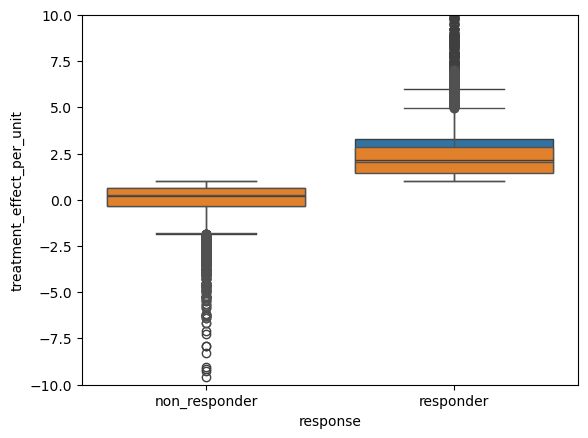

In [13]:
sns.boxplot(x='response',y='treatment_effect_per_unit',data=df)
plt.ylim(-10,10)

outliers=df.loc[(df['treatment_effect_per_unit']>7) | (df['treatment_effect_per_unit']<-7)]
df.drop(outliers.index,inplace=True)

df.treatment_effect_per_unit.describe()

sns.boxplot(x='response',y='treatment_effect_per_unit',data=df)
plt.ylim(-10,10)

plt.show()

In [ ]:
# Median IQR for the length of iCU stay and the median hour from start of infusion to sampling time

In [14]:
#Giovanni: nomenclature note
# df=pd.concat(data).groupby('patientunitstayid').first().reset_index() # for now we only keep the first transfusion

df['age_quartile']=pd.qcut(df.age,[.0,.25,.5,.75,1.],precision=1).astype(str)


# Add length of stay to df
df=merge_info(df, lengthStay_df, 'patientunitstayid')


# ---------------
# Add apache score
apache_concat=apache_df[['patientunitstayid', 'apache_score']]
apache_concat=apache_concat.drop_duplicates()
df=df.merge(apache_concat, on='patientunitstayid', how='left', validate='1:1')
# ---------------

temp=fluids_df.merge(df[['patientunitstayid','treatment_offset']],on='patientunitstayid')
temp['delta']=temp.transfusion_offset-temp.treatment_offset
temp=temp.groupby('patientunitstayid').apply(lambda data: data.sort_values(by='delta').iloc[-1,:],include_groups=True)
temp=temp.reset_index(drop=True).drop(['treatment_offset','delta','transfusion_offset'],axis=1)
df=df.merge(temp,on='patientunitstayid',how='left',validate='1:1')

df=df[df.treatment_effect.notna()] # removes patients with missing values on treatment effect
df=df[df.treatment_offset>=0] # remove patients who receives transfusion before ICU admission


print(df.shape)
df['z_score']=zscore(df['treatment_effect'])
norm_df=df[df['z_score'].abs()<=3]
df=norm_df

print(df.shape)
df['z_score_value']=zscore(df['treatment_value'])
norm_df=df[df['z_score_value'].abs()<=3]
df=norm_df
print(df.shape)

df['treatment_effect_per_unit'] = df.apply(compute_effect_per_unit, axis=1)
# df['treatment_effect_per_unit']=df['treatment_effect']/(df['treatment_value']/330.0)
# df['treatment_effect_per_unit'].describe()

df['HGB Increment (g/dL) Quartile']=pd.qcut(df.treatment_effect,[.0,.25,.5,.75,1.],precision=1).astype(str)
df['baseline_quartile']=pd.qcut(df.baseline,[.0,.25,.5,.75,1.],precision=1).astype(str)


# Vitals 
# NOTE: Please review-----
vp_temp=vitals.merge(df[['patientunitstayid', 'treatment_offset']],on='patientunitstayid')
# REMINDER: Need to change this; use something other than iloc[0:, 1:5] in case more features are added
vp_temp=vp_temp.groupby('patientunitstayid').apply(lambda data: data.iloc[0:, 1:5]
                                                   .mean(),include_groups=False)
vp_temp=vp_temp.reset_index()
df=df.merge(vp_temp,on='patientunitstayid',how='left',validate='1:1')

# df['has_sepsis'] = df['patientunitstayid'].isin(sep_df['patientunitstayid']).astype(int)
# df.has_sepsis.value_counts()

# sepsis_df=df[df['has_sepsis']==1]
# non_sepsis_df=df[df['has_sepsis']==0]

exclude=['_window_size','_offset','aggfunc']

categorical=['gender','age_quartile','ethnicity','icu_outcome','hosp_outcome', 
             'hematologic_type', 'kidney_type', 'condition_category'] # Removed GI as they were excluded above

continuous=['initial_weight','treatment_effect', 'treatment_effect_per_unit', 
            'treatment_value','treatment_offset','baseline',
           'Total_time']

# continuous=['initial_weight','treatment_effect', 'treatment_effect_per_unit', 
#             'treatment_value','treatment_offset','baseline','netTotal',
#            'Total_time', 'apache_score','SaO2', 'heartrate', 'respiration', 'bp']


(8567, 34)
(8468, 35)
(8366, 36)


In [15]:

exclude=['_window_size','_offset','aggfunc']

categorical=['gender','age_quartile','ethnicity','icu_outcome','hosp_outcome', 
             'hematologic_type', 'kidney_type', 'condition_category'] # Removed GI as they were excluded above

continuous=['initial_weight','treatment_effect', 'treatment_effect_per_unit', 
            'treatment_value','treatment_offset','baseline',
           'Total_time']

In [16]:
print(df.shape)
print(df.patientunitstayid.nunique())

(8366, 42)
8366


In [17]:
# change this to create table one for sepsis patients and non-sepsis patients
t1=TableOne(df,
         columns=categorical+continuous,
         categorical=categorical,
         groupby='response',
         pval=True,
         )
t1=rename_cols(t1)
# non_sepsis_t1


In [5]:
dd.columns

Index(['patientunitstayid', 'baseline', 'post_treatment', 'treatment_effect',
       'treatment_value', 'treatment_offset', '_offset', '_window_size',
       'n_baseline', 'n_post_treatment', 'aggfunc', 'age', 'gender',
       'ethnicity', 'admit_diagnosis', 'initial_weight', 'icu_outcome',
       'hosp_outcome', 'hematologic_type', 'kidney_type', 'condition_category',
       'units', 'treatment_effect_per_unit', 'response', 'age_quartile',
       'patienthealthsystemstayid', 'ICU_Stay', 'Time_prior_ICU',
       'hospitalDischargeOffset', 'Total_time', 'apache_score', 'netTotal',
       'intakeTotal', 'outputTotal', 'z_score', 'z_score_value',
       'HGB Increment (g/dL) Quartile', 'baseline_quartile', 'SaO2',
       'heartrate', 'respiration', 'bp'],
      dtype='object')

In [18]:
t1

Grouped by response  \
                                                                              Missing   
n                                                                                       
gender, n (%)                          Female                                           
                                       Male                                             
age_quartile, n (%)                    (17.9, 55.0]                                     
                                       (55.0, 66.0]                                     
                                       (66.0, 76.0]                                     
                                       (76.0, 91.0]                                     
ethnicity, n (%)                                                                        
                                       African American                                 
                                       Asian                                            
                                       Caucasian                                        
                                       Hispanic                                         
                                       Native American                                  
                                       Other/Unknown                                    
icu_outcome, n (%)                     deceased                                         
                                       discharged                                       
hosp_outcome, n (%)                    deceased                                         
                                       discharged                                       
hematologic_type, n (%)                Coagulopathy                                     
                                       Hematologic (Other)                              
                                       Leukemia                                         
                                       None                                             
                                       Pancytopenia                                     
                                       Sickle Cell Disease                              
                                       Thrombocytopenia                                 
                                       Neutropenia                                      
kidney_type, n (%)                     Dialysis Access                                  
                                       Kidney Failure                                   
                                       Kidney Surgery                                   
                                       Kidney Transplant                                
                                       None                                             
                                       Renal Disorder                                   
                                       Renal Obstruction                                
condition_category, n (%)              Cardiac                                          
                                       Endocrine/Metabolic                              
                                       Gastrointestinal                                 
                                       Hematologic                                      
                                       Infectious                                       
                                       Musculoskeletal/Orthopedic                       
                                       Neurologic                                       
                                       Obstetric/Gynecologic                            
                                       Oncologic                                        
                                       Other                                            
                                       Renal                 

In [28]:
t1.to_latex('revised_t1.tex')

In [19]:
df.columns

Index(['patientunitstayid', 'baseline', 'post_treatment', 'treatment_effect',
       'treatment_value', 'treatment_offset', '_offset', '_window_size',
       'n_baseline', 'n_post_treatment', 'aggfunc', 'age', 'gender',
       'ethnicity', 'admit_diagnosis', 'initial_weight', 'icu_outcome',
       'hosp_outcome', 'hematologic_type', 'kidney_type', 'condition_category',
       'units', 'treatment_effect_per_unit', 'response', 'age_quartile',
       'patienthealthsystemstayid', 'ICU_Stay', 'Time_prior_ICU',
       'hospitalDischargeOffset', 'Total_time', 'apache_score', 'netTotal',
       'intakeTotal', 'outputTotal', 'z_score', 'z_score_value',
       'HGB Increment (g/dL) Quartile', 'baseline_quartile', 'SaO2',
       'heartrate', 'respiration', 'bp'],
      dtype='object')

In [27]:
res = df[df['response'] == 'responder']['ICU_Stay'].describe()

non_res = df[df['response'] == 'non_responder']['ICU_Stay'].describe()

print("Responder")
print(res)
print()
print('median', res['50%'])
print('IQR', res['75%'] - res['25%'])
print("___________________________")
print("Non Responder")
print(non_res)
print()
print('median', non_res['50%'])
print('IQR', non_res['75%'] - non_res['25%'])


Responder
count        4830.0
mean     168.357046
std       219.65275
min             0.0
25%       48.666667
50%       94.708333
75%      205.666667
max          5925.7
Name: ICU_Stay, dtype: Float64

median 94.70833333333334
IQR 157.0
___________________________
Non Responder
count         3536.0
mean      169.771258
std        196.94316
min              0.0
25%           52.475
50%            101.9
75%       205.933333
max      2150.783333
Name: ICU_Stay, dtype: Float64

median 101.9
IQR 153.45833333333334


In [42]:
df[['patientunitstayid','treatment_effect_per_unit', 'Total_time', 'ICU_Stay']]

,patientunitstayid,treatment_effect_per_unit,Total_time,ICU_Stay
0,141233,-2.653266,382.35,261.416667
1,141304,1.443750,181.933333,110.65
2,141547,0.935000,287.466667,43.716667
3,142483,0.770000,778.583333,703.65
4,142623,3.090634,482.95,11.45
...,...,...,...,...
8361,3352986,6.335797,952.4,873.133333
8362,3353015,1.760000,1998.416667,429.333333
8363,3353145,6.904615,527.116667,242.75
8364,3353197,2.640000,3183.016667,497.85


In [48]:
test_df=read_gbq(PROCEDURES / "test.sql",project_id=PROJECT_ID)
test_df=test_df.sort_values(by=['patientunitstayid','offset'])
test_df.offset=test_df.offset/60
test_df.entry_offset=test_df.entry_offset/60
test_df.head()
test_df.columns
test_df.patientunitstayid.nunique()
test_df.offset.describe()



Downloading: 100%|██████████|


count        60871.0
mean       80.255742
std       168.506796
min     -2095.433333
25%              5.8
50%        25.966667
75%        84.616667
max      5658.583333
Name: offset, dtype: Float64

In [49]:
test_df

,patientunitstayid,itemid,offset,entry_offset,item,value,unit
46869,141233,16394525,5.083333,5.083333,Volume-Transfuse red blood cells,199.00,ml
18438,141233,16550721,29.866667,29.866667,Volume-Transfuse red blood cells,325.00,ml
56147,141233,11606807,48.533333,48.533333,Volume-Transfuse red blood cells,335.00,ml
32820,141266,17575759,26.35,26.35,Volume-Transfuse red blood cells,289.40,ml
56159,141266,15290836,51.283333,51.283333,Volume-Transfuse red blood cells,306.31,ml
...,...,...,...,...,...,...,...
16508,3353254,216265543,6.016667,6.016667,pRBCs,300.00,ml
21423,3353254,215587072,19.516667,19.516667,pRBCs,300.00,ml
30727,3353254,217416992,27.133333,27.133333,pRBCs,300.00,ml
44777,3353254,217473419,32.266667,32.266667,pRBCs,300.00,ml
